# 02 - Perceptrón

**AI sin humo** - Notas personales para entender deep learning desde cero.

El perceptrón es la unidad más básica de una red neuronal. Es donde todo empieza. Acá vemos cómo funciona, por qué necesitamos activaciones no lineales, cómo el dot product define la frontera de decisión, y cuáles son los límites de un perceptrón solo.

---

## Contenido

1. [La función lineal como base de todo](#funcion-lineal)
2. [Activación: quitarle lo lineal](#activacion)
3. [Perceptrón = lineal + activación](#perceptron-def)
4. [Perceptrón en 1D](#perceptron-1d)
5. [Perceptrón en 2D y el dot product como similaridad](#perceptron-2d)
6. [Frontera de decisión y el rol del bias](#frontera)
7. [Compuertas lógicas con perceptrones](#compuertas)
8. [Implementación con entrenamiento](#implementacion)
9. [Límites del perceptrón: el problema XOR](#xor)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

---

<a id='funcion-lineal'></a>
## 1. La función lineal como base de todo

Partimos de la función lineal porque es una de las funciones **más básicas existentes** para modelar algo.

$$z = w \cdot x + b$$

Donde:
- $x$: input (puede ser un escalar o un vector)
- $w$: peso (weight) — cuánto "importa" ese input
- $b$: sesgo (bias) — un offset, un empujón constante
- $z$: salida

La idea es simple: podemos agarrar inputs, pesarlos (multiplicarlos por w) y sumarles un sesgo. Eso es todo lo que hace una función lineal.

Pero es **lineal**: no importa qué valores tengan $w$ y $b$, siempre vamos a generar una recta (en 1D) o un hiperplano (en dimensiones más altas). Combinar dos funciones lineales da otra función lineal. No ganás expresividad.

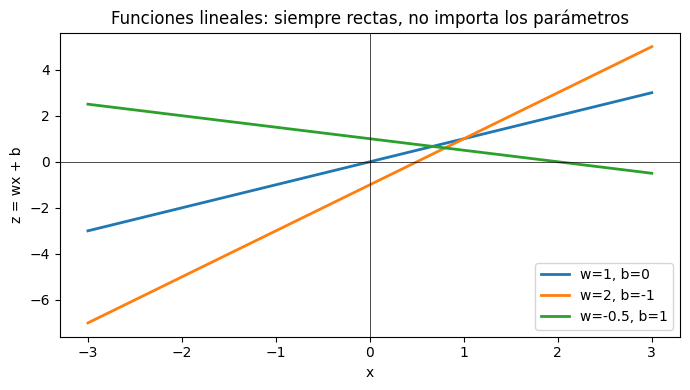

In [2]:
def linear(x, w, b):
    """Simple linear function."""
    return w * x + b


# Different w and b give different lines, but they're all lines
x = np.linspace(-3, 3, 100)

fig, ax = plt.subplots(figsize=(7, 4))
for w, b, label in [(1, 0, 'w=1, b=0'), (2, -1, 'w=2, b=-1'), (-0.5, 1, 'w=-0.5, b=1')]:
    ax.plot(x, linear(x, w, b), lw=2, label=label)

ax.axhline(y=0, color='black', linewidth=0.5)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('x')
ax.set_ylabel('z = wx + b')
ax.set_title('Funciones lineales: siempre rectas, no importa los parámetros')
ax.legend()
plt.tight_layout()
plt.show()

---

<a id='activacion'></a>
## 2. Activación: quitarle lo lineal

La función de activación se usa para **SACARLE LO LINEAL a la función lineal**. Sin activación, no importa cuántas funciones lineales encadenes o combines, siempre te queda algo lineal. Es como mezclar distintos tonos de blanco: siempre te queda blanco.

### La activación más básica: umbral (step/threshold)

Lo más básico es hacer un umbral:
- Si $z < 0$ → salida = -1 (o 0)
- Si $z \geq 0$ → salida = 1

Entonces ahí hicimos una **función no lineal básica** que puede servir para clasificación: todo lo que da positivo es una clase, todo lo que da negativo es la otra.

### Otras activaciones

- **Sigmoide**: transforma todo el espacio a valores entre 0 y 1 con una curva suave en forma de S. Sirve también para modelar probabilidades.
- **ReLU**: si es negativo, cero; si es positivo, dejarlo igual. Es la más usada en deep learning moderno (la vemos más adelante).

La idea general es: la activación **rompe la linealidad** y le da al modelo la capacidad de representar funciones más complejas.

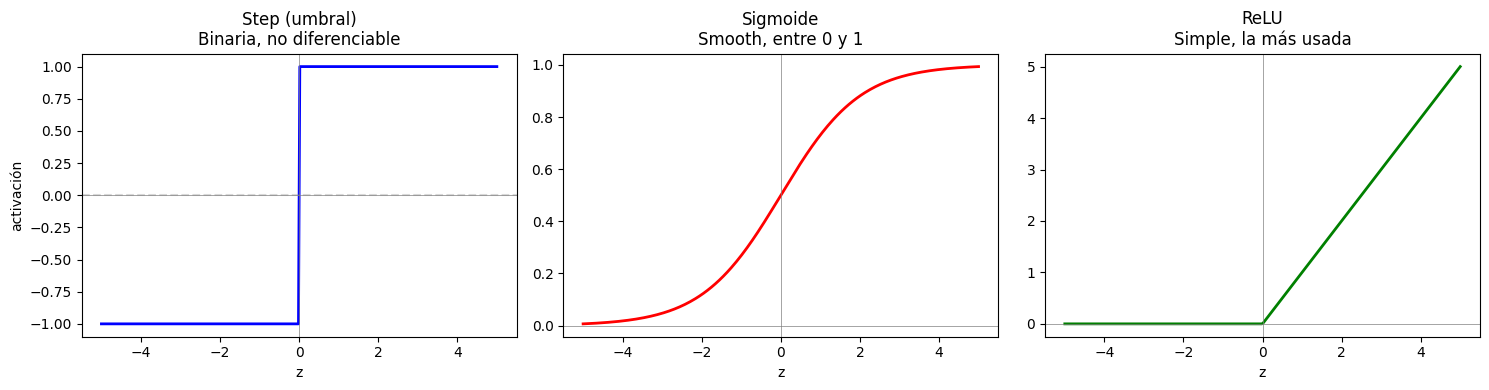

In [3]:
def step(z):
    """Step activation: threshold at 0."""
    return np.where(z >= 0, 1, -1)


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def relu(z):
    return np.maximum(0, z)


z = np.linspace(-5, 5, 300)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(z, step(z), 'b-', lw=2)
axes[0].set_title('Step (umbral)\nBinaria, no diferenciable')
axes[0].set_xlabel('z')
axes[0].set_ylabel('activación')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.3)

axes[1].plot(z, sigmoid(z), 'r-', lw=2)
axes[1].set_title('Sigmoide\nSmooth, entre 0 y 1')
axes[1].set_xlabel('z')

axes[2].plot(z, relu(z), 'g-', lw=2)
axes[2].set_title('ReLU\nSimple, la más usada')
axes[2].set_xlabel('z')

for ax in axes:
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()

---

<a id='perceptron-def'></a>
## 3. Perceptrón = lineal + activación

El **perceptrón** es simplemente eso: una función lineal seguida de una activación.

$$z = \mathbf{w} \cdot \mathbf{x} + b \quad \rightarrow \quad y = \text{activación}(z)$$

Con un threshold como activación: si $z < 0$ → $y = -1$, si no → $y = 1$.

![Perceptrón](../ai_notas/AI%20notas/image%206.png)

Es la unidad más básica de una red neuronal. Todo lo que vamos a ver después (shallow networks, deep networks, transformers) son **combinaciones de esta idea básica**.

---

<a id='perceptron-1d'></a>
## 4. Perceptrón en 1D

Empecemos con un solo input $x$ (un número).

El perceptrón calcula: $z = w \cdot x + b$

Dependiendo de los valores de $w$ y $b$, el **punto de corte** (donde $z = 0$) se mueve. Todo lo que queda de un lado del punto de corte se clasifica como una clase y lo del otro lado como la otra.

**Ejemplo**: si $w=1$ y $b=1$, entonces $z = x + 1$.
- El punto de corte es donde $z = 0$, o sea $x = -1$
- Si $x > -1$ → $z > 0$ → clase +1
- Si $x < -1$ → $z < 0$ → clase -1

Ese punto de corte es la **frontera de decisión**. En 1D es un punto. En 2D es una línea. En 3D es un plano. En general, un **hiperplano**.

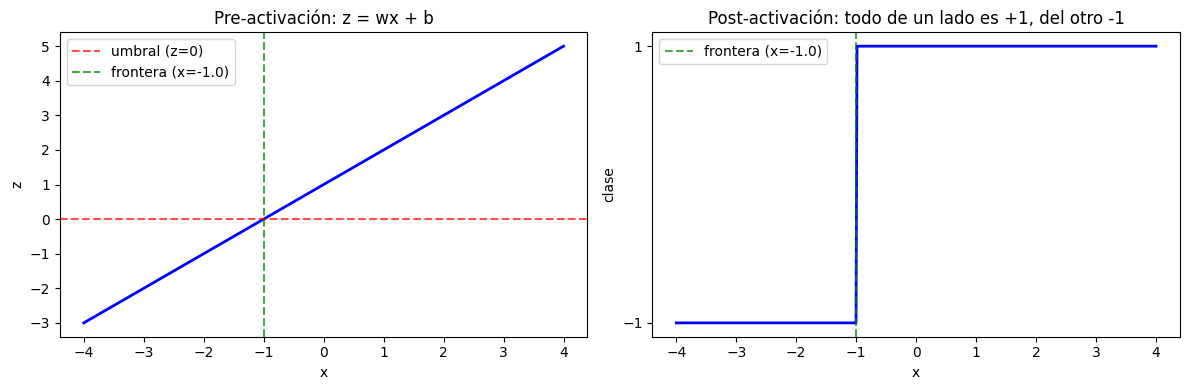

In [4]:
def perceptron_1d(x, w, b):
    """1D perceptron with step activation."""
    z = w * x + b
    return step(z)


x_range = np.linspace(-4, 4, 500)
w, b = 1.0, 1.0
boundary = -b / w  # where z = 0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear output (before activation)
axes[0].plot(x_range, linear(x_range, w, b), 'b-', lw=2)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.7, label='umbral (z=0)')
axes[0].axvline(x=boundary, color='green', linestyle='--', alpha=0.7, label=f'frontera (x={boundary:.1f})')
axes[0].set_title('Pre-activación: z = wx + b')
axes[0].set_xlabel('x')
axes[0].set_ylabel('z')
axes[0].legend()

# After activation
axes[1].plot(x_range, perceptron_1d(x_range, w, b), 'b-', lw=2)
axes[1].axvline(x=boundary, color='green', linestyle='--', alpha=0.7, label=f'frontera (x={boundary:.1f})')
axes[1].set_title('Post-activación: todo de un lado es +1, del otro -1')
axes[1].set_xlabel('x')
axes[1].set_ylabel('clase')
axes[1].set_yticks([-1, 1])
axes[1].legend()

plt.tight_layout()
plt.show()

---

<a id='perceptron-2d'></a>
## 5. Perceptrón en 2D y el dot product como similaridad

Con inputs 2D es lo mismo, pero ahora $\mathbf{w}$ es un vector 2D y la frontera de decisión es una **línea** (en vez de un punto).

$$z = w_1 \cdot x_1 + w_2 \cdot x_2 + b = \mathbf{w} \cdot \mathbf{x} + b$$

![Perceptrón 2D](../ai_notas/AI%20notas/image%207.png)

### ¿Cómo pensar en la frontera?

Se puede pensar que $\mathbf{w}$ (en este caso es 2D) es un vector y la frontera es **ortogonal** (perpendicular) a ese vector. Entonces mientras un punto esté más **alineado** al vector $\mathbf{w}$, más grande va a ser su valor $z$ y por lo tanto más se va a clasificar como clase +1.

Esto es lo mismo que pensar en el **dot product** (producto punto).

### Dot product como medida de alineación

Cuando tenemos dos vectores, el dot product multiplica cada componente de uno con el mismo componente del otro y después suma todo. Nos queda un solo **escalar** (un número).

$$\mathbf{w} \cdot \mathbf{x} = w_1 \cdot x_1 + w_2 \cdot x_2 = \sum_i w_i \cdot x_i$$

Esto nos dice **qué tan alineados están estos dos vectores**:

- Si ambos componentes son altos y del mismo signo → el dot product es **grande** (como es una multiplicación, si los dos son altos, va a pesar mucho en el total)
- Si uno es alto y el otro bajo → no suma tanto
- Si los dos son bajos → no aporta casi nada
- Si apuntan en direcciones opuestas → el dot product es **negativo**

Es una forma de medir **lo que es importante para ambos vectores**. Por eso se usa tanto en deep learning: es la operación fundamental que compara y combina información.

![Dot product como alineación](../ai_notas/AI%20notas/image%208.png)

---

<a id='frontera'></a>
## 6. Frontera de decisión y el rol del bias

La frontera de decisión es el lugar donde $z = 0$: $\mathbf{w} \cdot \mathbf{x} + b = 0$.

Todo lo que queda de un lado se clasifica como una clase, y del otro como la otra.

### ¿Qué hace el bias?

El bias $b$ **empuja el hiperplano** (la frontera) para un lado o el otro, siempre en la dirección de $\mathbf{w}$. Sin bias, la frontera pasa obligatoriamente por el origen (0, 0). Con bias, la podemos mover a donde necesitemos.

Pensalo así:
- $\mathbf{w}$ define la **orientación** de la frontera (para dónde mira)
- $b$ define la **posición** de la frontera (qué tan lejos del origen está)

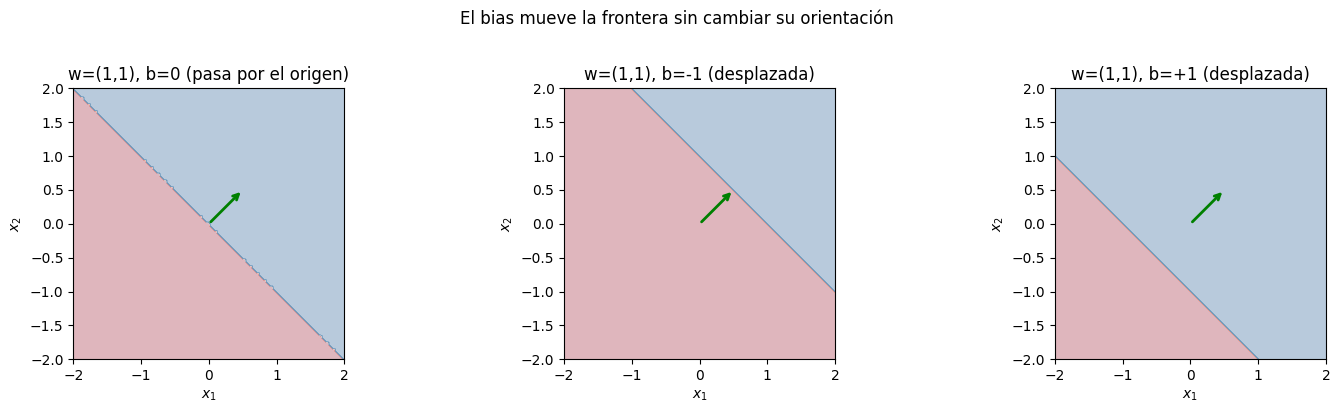

In [5]:
def perceptron_2d(x1, x2, w1, w2, b):
    """2D perceptron with step activation."""
    z = w1 * x1 + w2 * x2 + b
    return np.where(z >= 0, 1, -1)


# Show how bias moves the boundary
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

w1, w2 = 1.0, 1.0
x1_range = np.linspace(-2, 2, 200)
x2_range = np.linspace(-2, 2, 200)
X1, X2 = np.meshgrid(x1_range, x2_range)

for ax, b, title in zip(axes, [0, -1, 1], ['b=0 (pasa por el origen)', 'b=-1 (desplazada)', 'b=+1 (desplazada)']):
    Z = perceptron_2d(X1, X2, w1, w2, b)
    ax.contourf(X1, X2, Z, alpha=0.3, cmap='RdBu')
    ax.set_title(f'w=(1,1), {title}')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_aspect('equal')
    # Draw w vector
    ax.annotate('', xy=(w1*0.5, w2*0.5), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='green', lw=2))

plt.suptitle('El bias mueve la frontera sin cambiar su orientación', y=1.02)
plt.tight_layout()
plt.show()

---

<a id='compuertas'></a>
## 7. Compuertas lógicas con perceptrones

¿Qué pasa si a partir del perceptrón queremos aplicar algo de **lógica**, como OR, AND, NOT?

Se suele usar clasificación binaria para las primeras pruebas porque se quiere probar con **lógica booleana**, que es binaria. Y resulta que un perceptrón puede implementar AND, OR y NAND sin problemas.

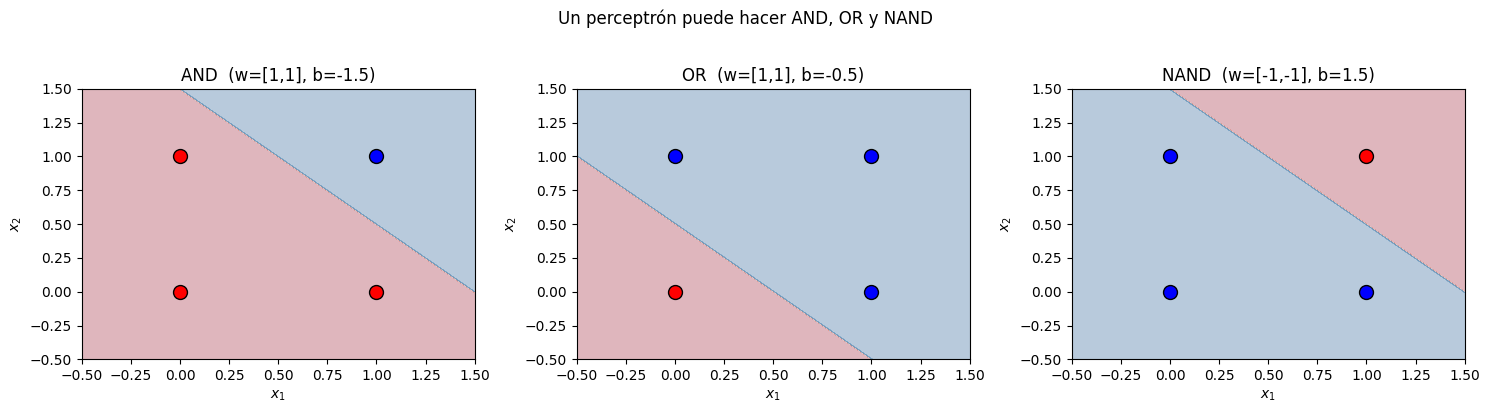

In [6]:
# Demonstrate AND, OR, NAND gates with a perceptron
gates = {
    'AND': {'w': [1, 1], 'b': -1.5, 'y': [-1, -1, -1, 1]},
    'OR':  {'w': [1, 1], 'b': -0.5, 'y': [-1, 1, 1, 1]},
    'NAND': {'w': [-1, -1], 'b': 1.5, 'y': [1, 1, 1, -1]},
}

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, gate) in zip(axes, gates.items()):
    w1, w2 = gate['w']
    b = gate['b']
    y = np.array(gate['y'])
    
    x1_range = np.linspace(-0.5, 1.5, 200)
    x2_range = np.linspace(-0.5, 1.5, 200)
    X1, X2 = np.meshgrid(x1_range, x2_range)
    Z = perceptron_2d(X1, X2, w1, w2, b)
    ax.contourf(X1, X2, Z, alpha=0.3, cmap='RdBu')
    
    for xi, yi in zip(X, y):
        color = 'blue' if yi == 1 else 'red'
        ax.scatter(xi[0], xi[1], c=color, s=100, edgecolors='black', zorder=5)
    
    ax.set_title(f'{name}  (w=[{w1},{w2}], b={b})')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

plt.suptitle('Un perceptrón puede hacer AND, OR y NAND', y=1.02)
plt.tight_layout()
plt.show()

---

<a id='implementacion'></a>
## 8. Implementación con entrenamiento

Ahora implementemos un perceptrón completo con entrenamiento. El algoritmo de entrenamiento del perceptrón es muy simple: por cada ejemplo, si lo clasifica mal, ajusta los pesos en la dirección correcta. Si lo clasifica bien, no hace nada.

In [7]:
class Perceptron:
    """Simple perceptron for binary classification."""
    
    def __init__(self, n_features, lr=0.1):
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.lr = lr
    
    def predict(self, x):
        z = np.dot(x, self.w) + self.b
        return np.where(z >= 0, 1, -1)
    
    def train(self, X, y, n_epochs=10):
        errors_per_epoch = []
        for epoch in range(n_epochs):
            errors = 0
            for xi, yi in zip(X, y):
                y_pred = self.predict(xi)
                if y_pred != yi:
                    # Update: move weights toward correct classification
                    self.w += self.lr * yi * xi
                    self.b += self.lr * yi
                    errors += 1
            errors_per_epoch.append(errors)
            if errors == 0:
                print(f"Convergió en epoch {epoch}: todos los ejemplos clasificados bien.")
                break
        return errors_per_epoch

In [12]:
# Train on AND gate
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([-1, -1, -1, 1])

p = Perceptron(n_features=2, lr=0.1)
errors = p.train(X, y_and, n_epochs=20)

print(f"\nPesos finales: w={p.w}, b={p.b:.2f}")
print(f"Predicciones: {[int(p.predict(xi)) for xi in X]}")
print(f"Esperado:     {y_and.tolist()}")

Convergió en epoch 3: todos los ejemplos clasificados bien.

Pesos finales: w=[0.2 0.1], b=-0.20
Predicciones: [-1, -1, -1, 1]
Esperado:     [-1, -1, -1, 1]


Funciona perfecto para AND. Pero ahora veamos qué pasa con XOR...

---

<a id='xor'></a>
## 9. Límites del perceptrón: el problema XOR

Hay cosas que **no pueden ser resueltas** por un simple perceptrón.

![Problema XOR](../ai_notas/AI%20notas/image%209.png)

El perceptrón puede clasificar todo lo que sea **linealmente separable**: lo que se puede separar con una sola línea recta (o hiperplano en dimensiones más altas).

El XOR **no es linealmente separable**. No existe ninguna línea recta que pueda separar los puntos $(0,0)$ y $(1,1)$ (que son clase -1) de los puntos $(0,1)$ y $(1,0)$ (que son clase +1). Probá mentalmente: no hay forma de trazar una sola recta que los separe.

Este fue un problema histórico famoso. Minsky y Papert publicaron un paper en 1969 mostrando esta limitación, lo que frenó la investigación en redes neuronales por años (el llamado "AI winter").

### La solución

**Combinar varios perceptrones**. Si uno solo no puede, quizás dos o tres sí. Eso nos lleva a las **shallow networks**, tema del siguiente notebook.

In [14]:
# Show that a single perceptron CANNOT solve XOR
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([-1, 1, 1, -1])  # XOR

p_xor = Perceptron(n_features=2, lr=0.1)
errors = p_xor.train(X, y_xor, n_epochs=100)

# Fix the IndexError: predict(xi) may return a scalar or 0-dim array, so use item() to extract the value
print(f"\nPredicciones después de 100 epochs: {[p_xor.predict(xi).item() for xi in X]}")
print(f"Esperado:                           {y_xor.tolist()}")
print(f"\nNunca converge. XOR no es linealmente separable.")


Predicciones después de 100 epochs: [1, 1, -1, -1]
Esperado:                           [-1, 1, 1, -1]

Nunca converge. XOR no es linealmente separable.


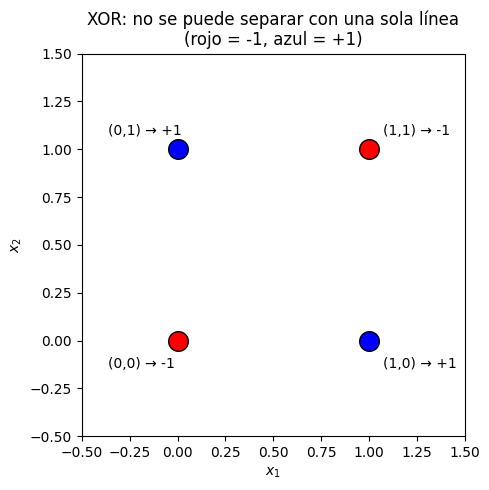

In [11]:
# Visualize: no single line can separate XOR
fig, ax = plt.subplots(figsize=(5, 5))

labels = ['(0,0) → -1', '(0,1) → +1', '(1,0) → +1', '(1,1) → -1']
offsets = [(-50, -20), (-50, 10), (10, -20), (10, 10)]

for xi, yi, label, offset in zip(X, y_xor, labels, offsets):
    color = 'blue' if yi == 1 else 'red'
    ax.scatter(xi[0], xi[1], c=color, s=200, edgecolors='black', zorder=5)
    ax.annotate(label, (xi[0], xi[1]), textcoords='offset points', xytext=offset, fontsize=10)

ax.set_xlim([-0.5, 1.5])
ax.set_ylim([-0.5, 1.5])
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('XOR: no se puede separar con una sola línea\n(rojo = -1, azul = +1)')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

---

## Resumen

| Concepto | Descripción |
|----------|-------------|
| **Función lineal** | $z = \mathbf{w} \cdot \mathbf{x} + b$. La base de todo. Simple pero limitada: siempre genera rectas/planos. |
| **Activación** | Función no lineal que se aplica después de la lineal. **Rompe la linealidad** para ganar expresividad. |
| **Perceptrón** | Función lineal + activación. La unidad más básica de una red neuronal. |
| **Dot product** | Mide **alineación** entre dos vectores. Es la operación fundamental del perceptrón. |
| **Frontera de decisión** | Donde $z = 0$. Separa las clases. Es **perpendicular** a $\mathbf{w}$. |
| **Bias** | Mueve la frontera sin cambiar su orientación. Sin bias, la frontera pasa por el origen. |
| **Linealmente separable** | Un problema donde las clases se pueden separar con una sola recta/plano. |
| **XOR** | Problema **no** linealmente separable. Un perceptrón solo no lo puede resolver. |

---

**Siguiente notebook →** [03 - Shallow Networks](./03_shallow_networks.ipynb): combinando perceptrones para resolver XOR y mucho más.